# Advanced Airline Data Analytics & Customer Revenue Analysis

## Project Overview
This notebook performs **end-to-end analytics** on airline passenger data including:
- **Advanced SQL queries** for data extraction and enrichment
- **Customer segmentation** and lifetime value analysis
- **Revenue analysis** by customer, route, and fare class
- **Statistical hypothesis testing** to validate business assumptions
- **Interactive visualizations** for business insights
- **AI-powered Q&A chatbot** that answers questions about the data using Phi API

## Key Questions We'll Answer:
1. Who are our high-value customers?
2. Which routes generate the most revenue?
3. What's the impact of fare class on revenue?
4. Are there seasonal patterns in bookings?
5. How does aircraft type affect flight profitability?
6. What customer segments exist based on behavior?
7. Are there significant differences in spending by customer segment?

In [37]:
# IMPORT LIBRARIES - All tools we need for analysis and visualization


# Data manipulation and analysis
import numpy as np  # Numerical operations and arrays
import pandas as pd  # DataFrames and data manipulation
import sqlite3  # Connection to SQLite database
from datetime import datetime, timedelta  # Working with dates and times

# Statistical analysis
from scipy import stats  # Statistical tests (t-test, chi-square, etc.)
from scipy.stats import linregress, mannwhitneyu, kruskal  # Specific tests

# Visualization libraries
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns  # Enhanced statistical visualizations
import plotly.express as px  # Interactive plots
import plotly.graph_objects as go  # Advanced interactive charts
from plotly.subplots import make_subplots  # Multiple subplots

# Machine learning and clustering
from sklearn.cluster import KMeans  # K-means clustering for segmentation
from sklearn.preprocessing import StandardScaler  # Normalize data for clustering
from sklearn.decomposition import PCA  # Principal Component Analysis for visualization


import json  # For working with JSON data

# General utilities
import warnings  # Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 100)  # Show max 100 rows
pd.set_option('display.float_format', lambda x: f'{x:.2f}' if abs(x) < 1e6 else f'{x:.0f}')  # Format numbers

%matplotlib inline
sns.set_style('whitegrid')  # Set nice background style for plots
plt.rcParams['figure.figsize'] = (14, 6)  # Set default plot size

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# DATABASE CONNECTION - Establish connection to SQLite database

db_path = "travel.sqlite"

# Create connection to SQLite database
conn = sqlite3.connect(db_path)

# Helper function to run SQL queries and get results as pandas DataFrame
def run_query(query_text):
    """
    Execute a SQL query and return results as a pandas DataFrame.
    This simplifies the process of running SQL queries throughout the notebook.
    """
    return pd.read_sql(query_text, conn)

# Test the connection by getting list of all tables
tables = run_query("""
    SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;
""")

print(" Database connected successfully!")
print(f"\n Available tables in database:")
print(tables['name'].values)
print(f"\nTotal tables: {len(tables)}")

 Database connected successfully!

 Available tables in database:
['FLIGHT_GEO_TICKET_2' 'FLIGHT_INFO' 'FLIGHT_INFO_ENRICHED_2'
 'aircrafts_data' 'airports_data' 'boarding_passes' 'bookings' 'flights'
 'seats' 'ticket_flights' 'tickets']

Total tables: 11


In [ ]:
overview_query = """
-- This query gives us counts of records in each key table
SELECT * from tickets
limit 10
"""

overview = run_query(overview_query)
print("\n TABLE SIZES & RECORD COUNTS:")
print(overview.to_string(index=False))

In [40]:
# DATA OVERVIEW - Get statistics on all important tables
# ============================================================================

# Get row counts and basic info about key tables
overview_query = """
-- This query gives us counts of records in each key table
SELECT 
    'flights' as table_name,
    (SELECT COUNT(*) FROM flights) as row_count,
    (SELECT COUNT(DISTINCT flight_id) FROM flights) as unique_ids
UNION ALL
SELECT 'bookings', COUNT(*), COUNT(DISTINCT book_ref) FROM bookings
UNION ALL
SELECT 'tickets', COUNT(*), COUNT(DISTINCT ticket_no) FROM tickets
UNION ALL
SELECT 'boarding_passes', COUNT(*), COUNT(DISTINCT ticket_no) FROM boarding_passes
UNION ALL
SELECT 'ticket_flights' , COUNT(*), COUNT(DISTINCT ticket_no) FROM ticket_flights
"""

overview = run_query(overview_query)
print("\n TABLE SIZES & RECORD COUNTS:")
print(overview.to_string(index=False))


 TABLE SIZES & RECORD COUNTS:
     table_name  row_count  unique_ids
        flights      33121       33121
       bookings     262788      262788
        tickets     366733      366733
boarding_passes     579686      238834
 ticket_flights    1045726      366733


In [41]:
# Get date range of data
date_range = run_query("""
    -- Check the time period covered by the data
SELECT 
    MIN(scheduled_departure) as earliest_flight,
    MAX(scheduled_departure) as latest_flight,
    CAST(
        julianday(SUBSTR(MAX(scheduled_departure), 1, 19)) - 
        julianday(SUBSTR(MIN(scheduled_departure), 1, 19)) 
    AS INT) as days_of_data
FROM flights
""")

print(f"\n📅 DATA TIME RANGE:")
print(date_range.to_string(index=False))


# Check for missing data
missing_data = run_query("""
    -- Count NULL values in important columns
    SELECT 
        COUNT(*) as total_bookings,
        SUM(CASE WHEN book_ref IS NULL THEN 1 ELSE 0 END) as missing_book_ref,
        SUM(CASE WHEN book_date IS NULL THEN 1 ELSE 0 END) as missing_book_date
    FROM bookings
""")

print(f"\n🔍 DATA QUALITY CHECK (Bookings Table):")
print(missing_data.to_string(index=False))


📅 DATA TIME RANGE:
       earliest_flight          latest_flight  days_of_data
2017-07-16 01:50:00+03 2017-09-14 20:55:00+03            60

🔍 DATA QUALITY CHECK (Bookings Table):
 total_bookings  missing_book_ref  missing_book_date
         262788                 0                  0


In [42]:
# QUERY 1: TOP CUSTOMERS BY REVENUE
# This identifies our most valuable customers and their spending patterns


top_customers_query = """
-- Find top customers by total spending
SELECT 
    t.passenger_id,
    COUNT(DISTINCT t.ticket_no) as total_tickets_purchased,
    COUNT(DISTINCT tf.flight_id) as total_flights_taken,
    COUNT(DISTINCT b.book_ref) as total_bookings,
    CAST(SUM(tf.amount) as INTEGER) as total_spent,
    CAST(AVG(tf.amount) as NUMERIC(10,2)) as avg_ticket_price,
    CAST(MAX(tf.amount) as INTEGER) as max_ticket_price,
    COUNT(DISTINCT ap_dep.city) as cities_visited,
    ROUND(CAST(SUM(tf.amount) as FLOAT) / COUNT(DISTINCT tf.flight_id), 2) as revenue_per_flight
FROM 
    tickets t
    JOIN bookings b ON t.book_ref = b.book_ref
    JOIN ticket_flights tf ON t.ticket_no = tf.ticket_no
    JOIN flights f ON tf.flight_id = f.flight_id
    JOIN airports_data ap_dep ON f.departure_airport = ap_dep.airport_code
GROUP BY 
    t.passenger_id
ORDER BY 
    total_spent DESC
LIMIT 50
"""

top_customers = run_query(top_customers_query)
print("\n TOP 50 CUSTOMERS BY REVENUE:")
print(f"\nTotal high-value customers analyzed: {len(top_customers)}")
print(f"Average spending of top customers: ${top_customers['total_spent'].mean():,.0f}")


 TOP 50 CUSTOMERS BY REVENUE:

Total high-value customers analyzed: 50
Average spending of top customers: $434,378


In [ ]:
top_customers.head(20)  # Display first 20 rows of top customers

In [44]:
# QUERY 2: ROUTE PROFITABILITY ANALYSIS
# Identify which routes generate most revenue and have best seat utilization


query = """WITH seat_counts AS (
    SELECT
        aircraft_code,
        COUNT(*) AS total_seats
    FROM seats
    GROUP BY aircraft_code
)

SELECT
    f.departure_airport,
    f.arrival_airport,
    fi.from_city AS departure_city,
    fi.to_city AS arrival_city,
    json_extract(a.model, '$.en') AS aircraft_model,

    COUNT(DISTINCT f.flight_id) AS number_of_flights,
    COUNT(DISTINCT tf.ticket_no) AS tickets_sold,

    CAST(SUM(tf.amount) AS INTEGER) AS total_revenue,

    ROUND(AVG(tf.amount),2) AS avg_ticket_price,

    sc.total_seats,

    ROUND(
        COUNT(DISTINCT tf.ticket_no) * 100.0 /
        (COUNT(DISTINCT f.flight_id) * sc.total_seats),
        2
    ) AS seat_occupancy_percent,

    ROUND(
        SUM(tf.amount) /
        COUNT(DISTINCT f.flight_id),
        0
    ) AS revenue_per_flight

FROM flights f

JOIN FLIGHT_INFO fi
    ON f.flight_id = fi.flight_id

JOIN aircrafts_data a
    ON f.aircraft_code = a.aircraft_code

JOIN seat_counts sc
    ON f.aircraft_code = sc.aircraft_code

LEFT JOIN ticket_flights tf
    ON f.flight_id = tf.flight_id

WHERE f.status IN ('Departed','Arrived')

GROUP BY
    f.departure_airport,
    f.arrival_airport,
    fi.from_city,
    fi.to_city,
    a.model,
    sc.total_seats

ORDER BY total_revenue DESC

LIMIT 30;"""

In [ ]:
route_revenue = run_query(query)
print("\n TOP 30 ROUTES BY REVENUE:")
print(f"\nAverage seat occupancy across top routes: {route_revenue['seat_occupancy_percent'].mean():.1f}%")
route_revenue.head(15)

In [46]:
# ============================================================================
# QUERY 3: FARE CLASS ANALYSIS
# Understand revenue contribution and volume by seat class (Economy, Business, etc.)
# ============================================================================

fare_class_query = """
-- Analyze revenue by fare class (seat class)
SELECT 
    tf.fare_conditions as seat_class,
    COUNT(DISTINCT tf.ticket_no) as tickets_sold,
    CAST(SUM(tf.amount) as INTEGER) as total_revenue,
    CAST(AVG(tf.amount) as NUMERIC(10,2)) as avg_price,
    CAST(MIN(tf.amount) as INTEGER) as min_price,
    CAST(MAX(tf.amount) as INTEGER) as max_price,
    
    COUNT(DISTINCT tf.flight_id) as flights_covered,
    ROUND(CAST(COUNT( tf.ticket_no) as FLOAT) / 
          (SELECT COUNT(ticket_no) FROM ticket_flights) * 100, 2) as percent_of_total_tickets,
    ROUND(CAST(SUM(tf.amount) as FLOAT) / 
          (SELECT SUM(amount) FROM ticket_flights) * 100, 2) as percent_of_total_revenue
FROM 
    ticket_flights tf
GROUP BY 
    tf.fare_conditions
ORDER BY 
    total_revenue DESC
"""

fare_class_analysis = run_query(fare_class_query)
print("\n REVENUE BY SEAT CLASS (Fare Conditions):")
print(fare_class_analysis.to_string(index=False))

# Store for later visualization
fare_class_data = fare_class_analysis.copy()


 REVENUE BY SEAT CLASS (Fare Conditions):
seat_class  tickets_sold  total_revenue  avg_price  min_price  max_price  flights_covered  percent_of_total_tickets  percent_of_total_revenue
   Economy        359720    14695684400   15959.81       3000      74500            22207                     88.05                     70.76
  Business         93386     5505179600   51143.42       9100     203300            11685                     10.29                     26.51
   Comfort         16308      566116900   32740.55      19900      47600              602                      1.65                      2.73


In [ ]:
# ============================================================================
# QUERY 4: AIRCRAFT PERFORMANCE ANALYSIS
# Evaluate how different aircraft types perform in terms of revenue and utilization
# ============================================================================

aircraft_query = """
-- Analyze performance by aircraft type
SELECT 
    a.aircraft_code,
    json_extract(a.model, '$.en') AS aircraft_model,
    a.range as max_range_km,
    COUNT(DISTINCT f.flight_id) as total_flights,
    COUNT(DISTINCT tf.ticket_no) as total_tickets,
    CAST(SUM(tf.amount) as INTEGER) as total_revenue,
    CAST(AVG(tf.amount) as NUMERIC(10,2)) as avg_ticket_price,
    COUNT(s.seat_no) as total_seats,
    ROUND(CAST(COUNT( tf.ticket_no) as FLOAT) / COUNT(s.seat_no), 2) as avg_occupancy_ratio,
    ROUND(CAST(SUM(tf.amount) as FLOAT) / COUNT(DISTINCT f.flight_id), 0) as revenue_per_flight,
    ROUND(CAST(SUM(tf.amount) as FLOAT) / COUNT(s.seat_no), 2) as revenue_per_seat
FROM 
    aircrafts_data a
    LEFT JOIN flights f ON a.aircraft_code = f.aircraft_code
    LEFT JOIN ticket_flights tf ON f.flight_id = tf.flight_id
    LEFT JOIN seats s ON a.aircraft_code = s.aircraft_code
WHERE 
    f.status IN ('Departed', 'Arrived')
GROUP BY 
    a.aircraft_code, 
    a.model,
    a.range
ORDER BY 
    total_revenue DESC
"""

aircraft_perf = run_query(aircraft_query)
print("\n AIRCRAFT PERFORMANCE METRICS:")
aircraft_perf.head()

In [ ]:
# ============================================================================
# QUERY 5: CUSTOMER BEHAVIOR SEGMENTATION DATA
# Gather metrics for customer segmentation analysis
# ============================================================================

segmentation_query = """
-- Extract customer behavior data for segmentation
WITH ReferenceDate AS (
    SELECT MAX(SUBSTR(book_date, 1, 19)) as max_date FROM bookings
)
SELECT 
    t.passenger_id,
    COUNT(DISTINCT b.book_ref) as booking_frequency,
    COUNT(DISTINCT tf.flight_id) as flight_frequency,
    CAST(SUM(tf.amount) as INTEGER) as lifetime_value,
    CAST(AVG(tf.amount) as NUMERIC(10,2)) as avg_transaction_value,
    ROUND(CAST(MAX(tf.amount) as FLOAT), 2) as max_transaction,
    ROUND(CAST(MIN(tf.amount) as FLOAT), 2) as min_transaction,
    
    -- Truncate to first 19 chars to remove +03
    CAST((julianday(SUBSTR(MAX(b.book_date), 1, 19)) - julianday(SUBSTR(MIN(b.book_date), 1, 19))) as INT) as days_as_customer,
    
    -- Truncate to first 19 chars for both sides of the calculation
    CAST((julianday(rd.max_date) - julianday(SUBSTR(MAX(b.book_date), 1, 19))) as INT) as days_since_last_booking,
    
    COUNT(DISTINCT CASE WHEN tf.fare_conditions = 'Business' THEN tf.ticket_no END) as business_class_flights,
    COUNT(DISTINCT CASE WHEN tf.fare_conditions = 'Economy' THEN tf.ticket_no END) as economy_class_flights,
    COUNT(DISTINCT ap.city) as cities_visited
FROM 
    tickets t
    JOIN bookings b ON t.book_ref = b.book_ref
    JOIN ticket_flights tf ON t.ticket_no = tf.ticket_no
    JOIN flights f ON tf.flight_id = f.flight_id
    JOIN airports_data ap ON f.arrival_airport = ap.airport_code
    CROSS JOIN ReferenceDate rd
GROUP BY 
    t.passenger_id
HAVING 
    COUNT(DISTINCT b.book_ref) > 0
ORDER BY 
    lifetime_value DESC;
"""

customer_segment_data = run_query(segmentation_query)
print(f"\n CUSTOMER SEGMENTATION DATA:")
print(f"Total customers in database: {len(customer_segment_data)}")
print(f"\nFirst 10 customers (sorted by lifetime value):")
customer_segment_data.head(5)

In [49]:
# ============================================================================
# QUERY 6: TEMPORAL TRENDS - SEASONAL PATTERNS
# Identify booking and revenue trends over time
# ============================================================================

temporal_query = """
-- Analyze revenue trends by month and season
SELECT 
    STRFTIME('%Y-%m', SUBSTR(b.book_date, 1, 19)) AS booking_month,
    CAST(STRFTIME('%m', SUBSTR(b.book_date, 1, 19)) AS INTEGER) AS month_number,
    COUNT(DISTINCT b.book_ref) AS total_bookings,
    COUNT(DISTINCT t.ticket_no) AS total_tickets,
    CAST(SUM(tf.amount) AS INTEGER) AS total_revenue,
    ROUND(AVG(tf.amount), 2) AS avg_ticket_price,
    COUNT(DISTINCT t.passenger_id) AS unique_customers
FROM bookings b
JOIN tickets t
    ON b.book_ref = t.book_ref
JOIN ticket_flights tf
    ON t.ticket_no = tf.ticket_no
GROUP BY booking_month, month_number
ORDER BY booking_month;
"""

temporal_data = run_query(temporal_query)
print("\n TEMPORAL TRENDS - BOOKING PATTERNS BY MONTH:")
temporal_data


 TEMPORAL TRENDS - BOOKING PATTERNS BY MONTH:


,booking_month,month_number,total_bookings,total_tickets,total_revenue,avg_ticket_price,unique_customers
0,2017-06,6,7303,10160,557361000,19338.04,10160
1,2017-07,7,167062,232755,13234251800,19979.03,232755
2,2017-08,8,88423,123818,6975368100,19676.80,123818


In [50]:
# ============================================================================
# QUERY 7: FLIGHT STATUS & OPERATIONAL METRICS
# Analyze flight cancellations, delays, and their impact on revenue
# ============================================================================

flight_status_query = """
-- Analyze operational metrics by flight status
SELECT 
    f.status,
    COUNT(DISTINCT f.flight_id) as total_flights,
    COUNT(DISTINCT tf.ticket_no) as tickets_associated,
    CAST(SUM(tf.amount) as INTEGER) as potential_revenue,
    CAST(AVG(tf.amount) as NUMERIC(10,2)) as avg_ticket_price,
    ROUND(CAST(COUNT(DISTINCT f.flight_id) as FLOAT) / 
          (SELECT COUNT(DISTINCT flight_id) FROM flights) * 100, 2) as percent_of_all_flights
          
FROM 
    flights f
    LEFT JOIN ticket_flights tf ON f.flight_id = tf.flight_id
GROUP BY 
    f.status
ORDER BY 
    total_flights DESC
"""

flight_status = run_query(flight_status_query)
print("\n FLIGHT STATUS & OPERATIONAL IMPACT:")
flight_status


 FLIGHT STATUS & OPERATIONAL IMPACT:


,status,total_flights,tickets_associated,potential_revenue,avg_ticket_price,percent_of_all_flights
0,Arrived,16707,237157,11427863000,19880.42,50.44
1,Scheduled,15383,186005,8832439600,19787.48,46.44
2,On Time,518,18635,406410800,19512.71,1.56
3,Cancelled,414,0,NaN,NaN,1.25
4,Departed,58,2275,66583400,29267.43,0.18
5,Delayed,41,1428,33684100,23588.31,0.12


In [ ]:
# ============================================================================
# QUERY 8: HUB ANALYSIS - WHICH AIRPORTS ARE HUBS?
# Identify major hubs based on flight volume and revenue
# ============================================================================

hub_analysis_query = """
-- Identify hub airports by analyzing incoming and outgoing flights
SELECT 
    ap.airport_code,
    json_extract(ap.city, '$.en') AS city,
    (SELECT COUNT(DISTINCT flight_id) FROM flights WHERE departure_airport = ap.airport_code) as outbound_flights,
    (SELECT COUNT(DISTINCT flight_id) FROM flights WHERE arrival_airport = ap.airport_code) as inbound_flights,
    (SELECT COUNT(DISTINCT flight_id) FROM flights WHERE departure_airport = ap.airport_code) +
    (SELECT COUNT(DISTINCT flight_id) FROM flights WHERE arrival_airport = ap.airport_code) as total_flights,
    CAST((SELECT SUM(amount) FROM ticket_flights tf 
          JOIN flights f ON tf.flight_id = f.flight_id 
          WHERE f.departure_airport = ap.airport_code OR f.arrival_airport = ap.airport_code) as INTEGER) as total_revenue
FROM 
    airports_data ap
WHERE 
    ap.airport_code IN (SELECT DISTINCT departure_airport FROM flights)
    OR ap.airport_code IN (SELECT DISTINCT arrival_airport FROM flights)
ORDER BY 
    total_flights DESC
LIMIT 20
"""

hub_analysis = run_query(hub_analysis_query)
print("\n TOP HUB AIRPORTS:")
hub_analysis

In [52]:
# ============================================================================
# EDA 1: REVENUE DISTRIBUTIONS
# Understand how revenue is distributed across customers and flights
# ============================================================================

print("\n" + "="*70)
print("EXPLORATORY DATA ANALYSIS - REVENUE DISTRIBUTIONS")
print("="*70)

# Statistics on customer lifetime value
print("\n CUSTOMER LIFETIME VALUE DISTRIBUTION:")
print(customer_segment_data['lifetime_value'].describe())
print(f"\nSkewness: {customer_segment_data['lifetime_value'].skew():.2f}")
print(f"(Positive = right-skewed, most customers are low-value)")

# Statistics on transaction values
print(f"\n INDIVIDUAL TICKET PRICE DISTRIBUTION:")
all_ticket_prices = run_query("SELECT amount FROM ticket_flights")
print(all_ticket_prices['amount'].describe())
print(f"\nSkewness: {all_ticket_prices['amount'].skew():.2f}")


EXPLORATORY DATA ANALYSIS - REVENUE DISTRIBUTIONS

 CUSTOMER LIFETIME VALUE DISTRIBUTION:
count   366733.00
mean     56626.98
std      48219.67
min       3400.00
25%      26000.00
50%      43600.00
75%      68400.00
max     529500.00
Name: lifetime_value, dtype: float64

Skewness: 2.34
(Positive = right-skewed, most customers are low-value)

 INDIVIDUAL TICKET PRICE DISTRIBUTION:
count     1045726
mean     19858.91
std      22612.39
min       3000.00
25%       7200.00
50%      13400.00
75%      23100.00
max     203300.00
Name: amount, dtype: float64

Skewness: 4.02


In [53]:
# ============================================================================
# EDA 2: CUSTOMER BEHAVIOR ANALYSIS
# Analyze customer engagement patterns and behavior
# ============================================================================

print("\n CUSTOMER BEHAVIOR METRICS:")
print(f"\nBooking Frequency (bookings per customer):")
print(customer_segment_data['booking_frequency'].describe())

print(f"\nFlight Frequency (flights per customer):")
print(customer_segment_data['flight_frequency'].describe())

print(f"\nDays Since Last Booking:")
print(customer_segment_data['days_since_last_booking'].describe())

# Calculate customer segments based on recency
recent_customers = len(customer_segment_data[customer_segment_data['days_since_last_booking'] <= 30])
dormant_customers = len(customer_segment_data[customer_segment_data['days_since_last_booking'] > 30])

print(f"\n CUSTOMER RECENCY ANALYSIS:")
print(f"  Recent customers (booked in last 30 days): {recent_customers} ({recent_customers/len(customer_segment_data)*100:.1f}%)")
print(f"  Dormant customers (no booking in 30+ days): {dormant_customers} ({dormant_customers/len(customer_segment_data)*100:.1f}%)")


 CUSTOMER BEHAVIOR METRICS:

Booking Frequency (bookings per customer):
count   366733.00
mean         1.00
std          0.00
min          1.00
25%          1.00
50%          1.00
75%          1.00
max          1.00
Name: booking_frequency, dtype: float64

Flight Frequency (flights per customer):
count   366733.00
mean         2.85
std          1.16
min          1.00
25%          2.00
50%          2.00
75%          4.00
max          6.00
Name: flight_frequency, dtype: float64

Days Since Last Booking:
count   366733.00
mean        22.16
std         13.68
min          0.00
25%         10.00
50%         22.00
75%         34.00
max         55.00
Name: days_since_last_booking, dtype: float64

 CUSTOMER RECENCY ANALYSIS:
  Recent customers (booked in last 30 days): 249081 (67.9%)
  Dormant customers (no booking in 30+ days): 117652 (32.1%)


In [54]:
# ============================================================================
# EDA 3: SEAT CLASS PREFERENCE ANALYSIS
# Understand customer preference for different seat classes
# ============================================================================

print("\n SEAT CLASS ANALYSIS:")
print(f"\nBusiness class tickets sold: {customer_segment_data['business_class_flights'].sum():.0f}")
print(f"Economy class tickets sold: {customer_segment_data['economy_class_flights'].sum():.0f}")

business_pct = (customer_segment_data['business_class_flights'].sum() / 
                 (customer_segment_data['business_class_flights'].sum() + 
                  customer_segment_data['economy_class_flights'].sum()) * 100)
print(f"\nBusiness class % of total: {business_pct:.1f}%")

# Find customers who prefer business class
business_preference = customer_segment_data[
    (customer_segment_data['business_class_flights'] > 0) & 
    (customer_segment_data['business_class_flights'] >= customer_segment_data['economy_class_flights'])
]
print(f"\nCustomers with business class preference: {len(business_preference)} ({len(business_preference)/len(customer_segment_data)*100:.1f}%)")


 SEAT CLASS ANALYSIS:

Business class tickets sold: 93386
Economy class tickets sold: 359720

Business class % of total: 20.6%

Customers with business class preference: 93386 (25.5%)


In [55]:
# ============================================================================
# TEST 1: DO DIFFERENT SEAT CLASSES HAVE DIFFERENT AVERAGE PRICES?
# Hypothesis: Business class tickets cost significantly more than Economy
# ============================================================================

print("\n" + "="*70)
print("STATISTICAL HYPOTHESIS TESTING")
print("="*70)

# Get ticket prices by fare class
fare_comparison_query = """
    SELECT fare_conditions, amount 
    FROM ticket_flights 
    WHERE fare_conditions IN ('Business', 'Economy')
"""

fare_prices = run_query(fare_comparison_query)

business_prices = fare_prices[fare_prices['fare_conditions'] == 'Business']['amount']
economy_prices = fare_prices[fare_prices['fare_conditions'] == 'Economy']['amount']

# Perform t-test
t_stat, p_value = stats.ttest_ind(business_prices, economy_prices)

print("\n TEST 1: FARE CLASS PRICING DIFFERENCE")
print(f"Null Hypothesis: Business and Economy classes have the same average price")
print(f"\nBusiness Class Stats:")
print(f"  Mean: ${business_prices.mean():.2f}")
print(f"  Std Dev: ${business_prices.std():.2f}")
print(f"  Sample size: {len(business_prices)}")
print(f"\nEconomy Class Stats:")
print(f"  Mean: ${economy_prices.mean():.2f}")
print(f"  Std Dev: ${economy_prices.std():.2f}")
print(f"  Sample size: {len(economy_prices)}")
print(f"\nT-Test Results:")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.2e}")
print(f"  Result: {'✅ SIGNIFICANT DIFFERENCE' if p_value < 0.05 else '❌ NO SIGNIFICANT DIFFERENCE'} (α=0.05)")
print(f"\n Interpretation: Business class costs {((business_prices.mean()/economy_prices.mean() - 1)*100):.1f}% more on average")


STATISTICAL HYPOTHESIS TESTING

 TEST 1: FARE CLASS PRICING DIFFERENCE
Null Hypothesis: Business and Economy classes have the same average price

Business Class Stats:
  Mean: $51143.42
  Std Dev: $46924.00
  Sample size: 107642

Economy Class Stats:
  Mean: $15959.81
  Std Dev: $13703.85
  Sample size: 920793

T-Test Results:
  T-statistic: 547.0869
  P-value: 0.00e+00
  Result: ✅ SIGNIFICANT DIFFERENCE (α=0.05)

 Interpretation: Business class costs 220.5% more on average


In [56]:
# ============================================================================
# TEST 2: DO DIFFERENT AIRCRAFT TYPES GENERATE SIGNIFICANTLY DIFFERENT REVENUE?
# Hypothesis: Aircraft type affects revenue generation
# ============================================================================

print("\n TEST 2: AIRCRAFT TYPE IMPACT ON REVENUE PER TICKET")
print(f"Null Hypothesis: All aircraft types generate the same average revenue per ticket")
print(f"Alternate Hypothesis: At least one aircraft type generates significantly different revenue per ticket")

# Get revenue data by aircraft type
aircraft_revenue_query = """
    SELECT 
        f.aircraft_code,
        json_extract(a.model, '$.en') AS aircraft_model,
        tf.amount
    FROM ticket_flights tf
    JOIN flights f ON tf.flight_id = f.flight_id
    JOIN aircrafts_data a ON f.aircraft_code = a.aircraft_code
    WHERE f.status IN ('Departed', 'Arrived')
"""

aircraft_revenue_data = run_query(aircraft_revenue_query)

# Group revenue by aircraft
aircraft_groups = [group['amount'].values for name, group in aircraft_revenue_data.groupby('aircraft_code')]

# Perform ANOVA (Analysis of Variance) test
f_stat, p_value_anova = stats.f_oneway(*aircraft_groups)

print(f"\nNumber of aircraft types tested: {len(aircraft_groups)}")
print(f"\nANOVA Results:")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_value_anova:.2e}")
print(f"  Result: {'✅ SIGNIFICANT DIFFERENCE' if p_value_anova < 0.05 else '❌ NO SIGNIFICANT DIFFERENCE'} (α=0.05)")
print(f"\nTop 5 Aircraft by Average Revenue:")
aircraft_avg = aircraft_revenue_data.groupby('aircraft_model')['amount'].agg(['mean', 'count']).sort_values('mean', ascending=False)
aircraft_avg


 TEST 2: AIRCRAFT TYPE IMPACT ON REVENUE PER TICKET
Null Hypothesis: All aircraft types generate the same average revenue per ticket
Alternate Hypothesis: At least one aircraft type generates significantly different revenue per ticket

Number of aircraft types tested: 8

ANOVA Results:
  F-statistic: 20673.2084
  P-value: 0.00e+00
  Result: ✅ SIGNIFICANT DIFFERENCE (α=0.05)

Top 5 Aircraft by Average Revenue:


,mean,count
aircraft_model,,
Airbus A319-100,51305.42,29309
Boeing 767-300,34805.05,68585
Boeing 777-300,23860.63,81563
Boeing 737-300,16503.30,47517
Airbus A321-200,15472.49,57390
Sukhoi Superjet-100,14070.44,200954
Bombardier CRJ-200,13196.87,83661
Cessna 208 Caravan,6615.56,8126


In [57]:
# ============================================================================
# TEST 3: IS THERE SEASONAL EFFECT ON BOOKING VOLUME?
# Hypothesis: Different months have significantly different booking volumes
# ============================================================================

print("\n TEST 3: SEASONAL BOOKING PATTERNS")
print(f"Null Hypothesis: All months have similar booking volumes")

# Get booking volume by month
monthly_bookings = temporal_data[['month_number', 'total_bookings']].copy()

# Group by month and get statistics
month_stats = temporal_data.groupby('month_number')['total_bookings'].agg(['mean', 'std', 'count'])
print(f"\nMonthly Booking Statistics:")
print(month_stats.to_string())

# Check for trend with correlation
correlation = temporal_data['month_number'].corr(temporal_data['total_bookings'])
print(f"\nCorrelation between month number and booking volume: {correlation:.3f}")
print(f"Interpretation: {'Strong' if abs(correlation) > 0.7 else 'Moderate' if abs(correlation) > 0.3 else 'Weak'} seasonal pattern")


 TEST 3: SEASONAL BOOKING PATTERNS
Null Hypothesis: All months have similar booking volumes

Monthly Booking Statistics:
                  mean  std  count
month_number                      
6              7303.00  NaN      1
7            167062.00  NaN      1
8             88423.00  NaN      1

Correlation between month number and booking volume: 0.508
Interpretation: Moderate seasonal pattern


In [58]:
# ============================================================================
# TEST 4: DO HIGH-FREQUENCY CUSTOMERS HAVE DIFFERENT SPENDING PATTERNS?
# Hypothesis: Frequent customers spend significantly more per ticket
# ============================================================================

print("\n TEST 4: FREQUENT BUYER PREMIUM (Do frequent customers spend more?)")
print(f"Null Hypothesis: Frequent and infrequent customers have the same avg transaction value")

# Define frequent vs infrequent based on booking frequency median
median_freq = customer_segment_data['avg_transaction_value'].median()



 TEST 4: FREQUENT BUYER PREMIUM (Do frequent customers spend more?)
Null Hypothesis: Frequent and infrequent customers have the same avg transaction value


In [59]:
frequent = customer_segment_data[customer_segment_data['avg_transaction_value'] >= median_freq]['lifetime_value']
infrequent = customer_segment_data[customer_segment_data['avg_transaction_value'] < median_freq]['lifetime_value']

In [60]:
# Mann-Whitney U test (non-parametric alternative to t-test)
u_stat, p_value_mw = mannwhitneyu(frequent, infrequent)


print(f"\nMann-Whitney U Test Results:")
print(f"  U-statistic: {u_stat:.4f}")
print(f"  P-value: {p_value_mw:.2e}")
print(f"  Result: {'✅ SIGNIFICANT DIFFERENCE' if p_value_mw < 0.05 else '❌ NO SIGNIFICANT DIFFERENCE'} (α=0.05)")
print(f"\n Interpretation: Frequent customers spend {((frequent.mean()/infrequent.mean() - 1)*100):.1f}% {'more' if frequent.mean() > infrequent.mean() else 'less'} on average")


Mann-Whitney U Test Results:
  U-statistic: 31094723717.0000
  P-value: 0.00e+00
  Result: ✅ SIGNIFICANT DIFFERENCE (α=0.05)

 Interpretation: Frequent customers spend 199.8% more on average



Generating Revenue Distribution Visualizations...


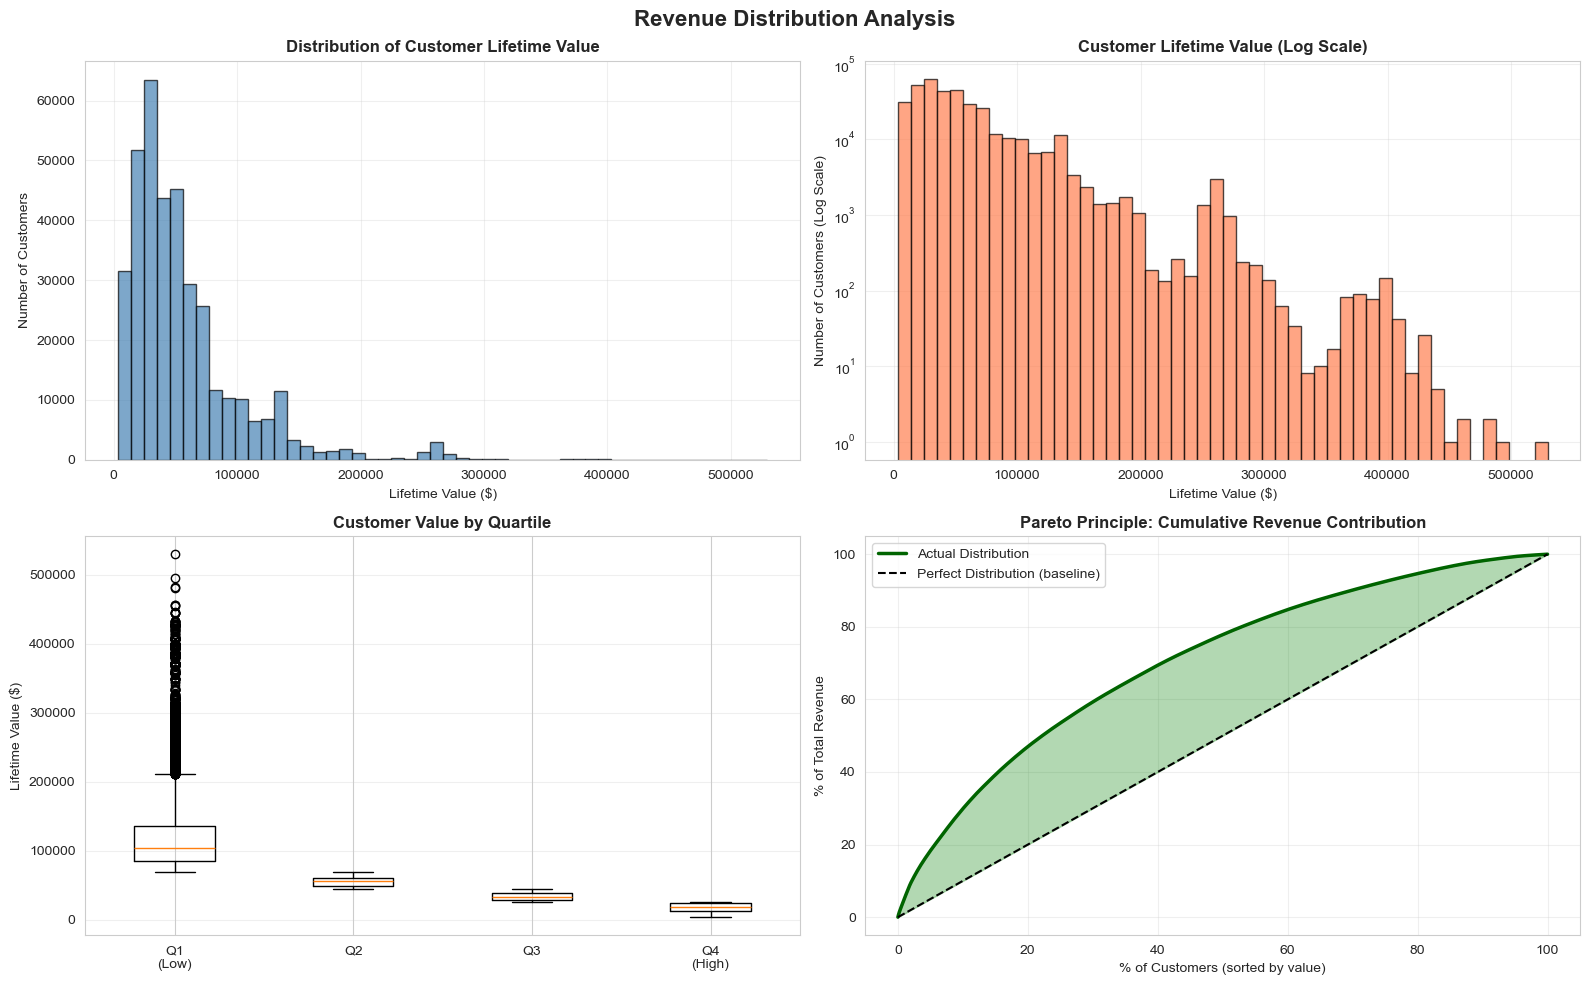

 Revenue distribution visualization complete!


In [61]:
# ============================================================================
# VIZ 1: REVENUE DISTRIBUTION ANALYSIS
# Show how revenue is distributed across customers (Pareto principle)
# ============================================================================

print("\nGenerating Revenue Distribution Visualizations...")

# Create subplots for revenue analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Revenue Distribution Analysis', fontsize=16, fontweight='bold')

# Plot 1: Histogram of customer lifetime value
axes[0, 0].hist(customer_segment_data['lifetime_value'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Customer Lifetime Value', fontweight='bold')
axes[0, 0].set_xlabel('Lifetime Value ($)')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Log-scale histogram (shows long tail better)
axes[0, 1].hist(customer_segment_data['lifetime_value'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_yscale('log')  # Log scale to see tail better
axes[0, 1].set_title('Customer Lifetime Value (Log Scale)', fontweight='bold')
axes[0, 1].set_xlabel('Lifetime Value ($)')
axes[0, 1].set_ylabel('Number of Customers (Log Scale)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Box plot of lifetime value by quartile
quartiles = pd.qcut(customer_segment_data['lifetime_value'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
data_by_quartile = [customer_segment_data[quartiles == q]['lifetime_value'].values for q in quartiles.unique()]
axes[1, 0].boxplot(data_by_quartile, labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4\n(High)'])
axes[1, 0].set_title('Customer Value by Quartile', fontweight='bold')
axes[1, 0].set_ylabel('Lifetime Value ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Cumulative revenue contribution (Pareto)
sorted_customers = customer_segment_data.sort_values('lifetime_value', ascending=False).reset_index(drop=True)
cumsum_revenue = sorted_customers['lifetime_value'].cumsum()
total_revenue = cumsum_revenue.iloc[-1]
cumsum_pct = (cumsum_revenue / total_revenue * 100).values
customer_pct = (np.arange(1, len(sorted_customers) + 1) / len(sorted_customers) * 100)

axes[1, 1].plot(customer_pct, cumsum_pct, linewidth=2.5, color='darkgreen', label='Actual Distribution')
axes[1, 1].plot([0, 100], [0, 100], 'k--', linewidth=1.5, label='Perfect Distribution (baseline)')
axes[1, 1].fill_between(customer_pct, cumsum_pct, customer_pct, alpha=0.3, color='green')
axes[1, 1].set_title('Pareto Principle: Cumulative Revenue Contribution', fontweight='bold')
axes[1, 1].set_xlabel('% of Customers (sorted by value)')
axes[1, 1].set_ylabel('% of Total Revenue')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(" Revenue distribution visualization complete!")


Generating Fare Class Analysis Visualizations...


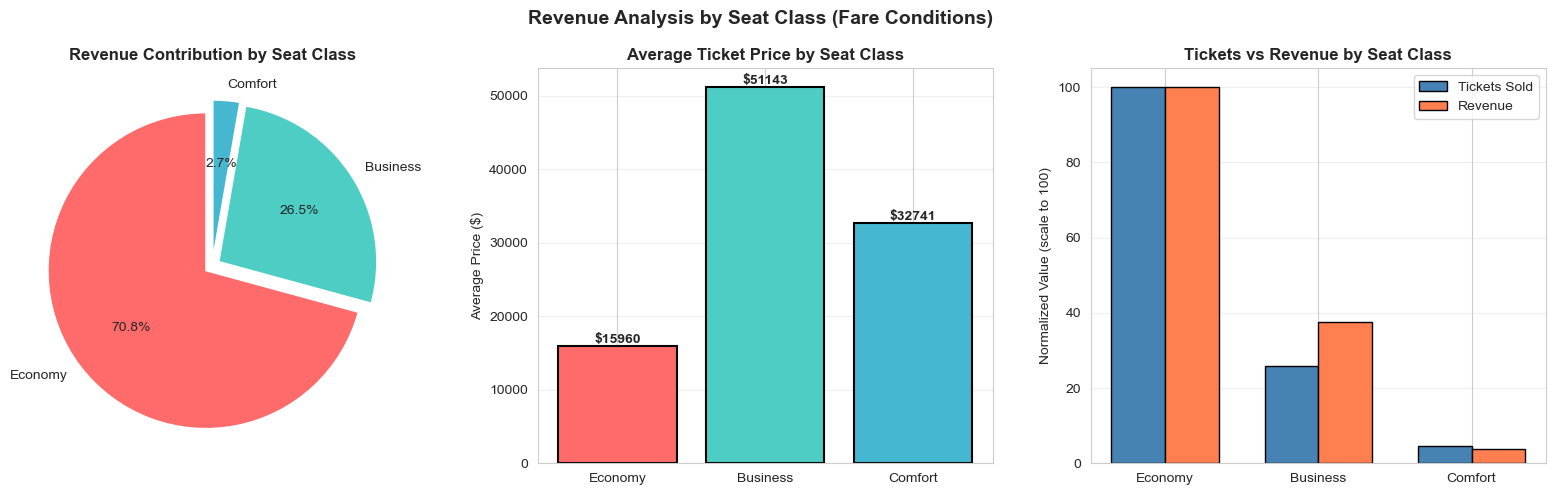

✅ Fare class visualization complete!


In [62]:
# ============================================================================
# VIZ 2: FARE CLASS ANALYSIS
# Show revenue and volume by seat class
# ============================================================================

print("\nGenerating Fare Class Analysis Visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Revenue Analysis by Seat Class (Fare Conditions)', fontsize=14, fontweight='bold')

# Plot 1: Revenue by fare class (pie chart)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].pie(fare_class_data['total_revenue'], labels=fare_class_data['seat_class'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05, 0.05))
axes[0].set_title('Revenue Contribution by Seat Class', fontweight='bold')

# Plot 2: Average ticket price by class
bars = axes[1].bar(fare_class_data['seat_class'], fare_class_data['avg_price'], color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_title('Average Ticket Price by Seat Class', fontweight='bold')
axes[1].set_ylabel('Average Price ($)')
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')


# Plot 3: Volume vs Revenue comparison
x = np.arange(len(fare_class_data))
width = 0.35
# Normalize for comparison (scale to 0-100)
tickets_norm = (fare_class_data['tickets_sold'] / fare_class_data['tickets_sold'].max()) * 100
revenue_norm = (fare_class_data['total_revenue'] / fare_class_data['total_revenue'].max()) * 100

bars1 = axes[2].bar(x - width/2, tickets_norm, width, label='Tickets Sold', color='steelblue', edgecolor='black')
bars2 = axes[2].bar(x + width/2, revenue_norm, width, label='Revenue', color='coral', edgecolor='black')
axes[2].set_title('Tickets vs Revenue by Seat Class', fontweight='bold')
axes[2].set_ylabel('Normalized Value (scale to 100)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(fare_class_data['seat_class'])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Fare class visualization complete!")





Generating Top Routes Visualizations...


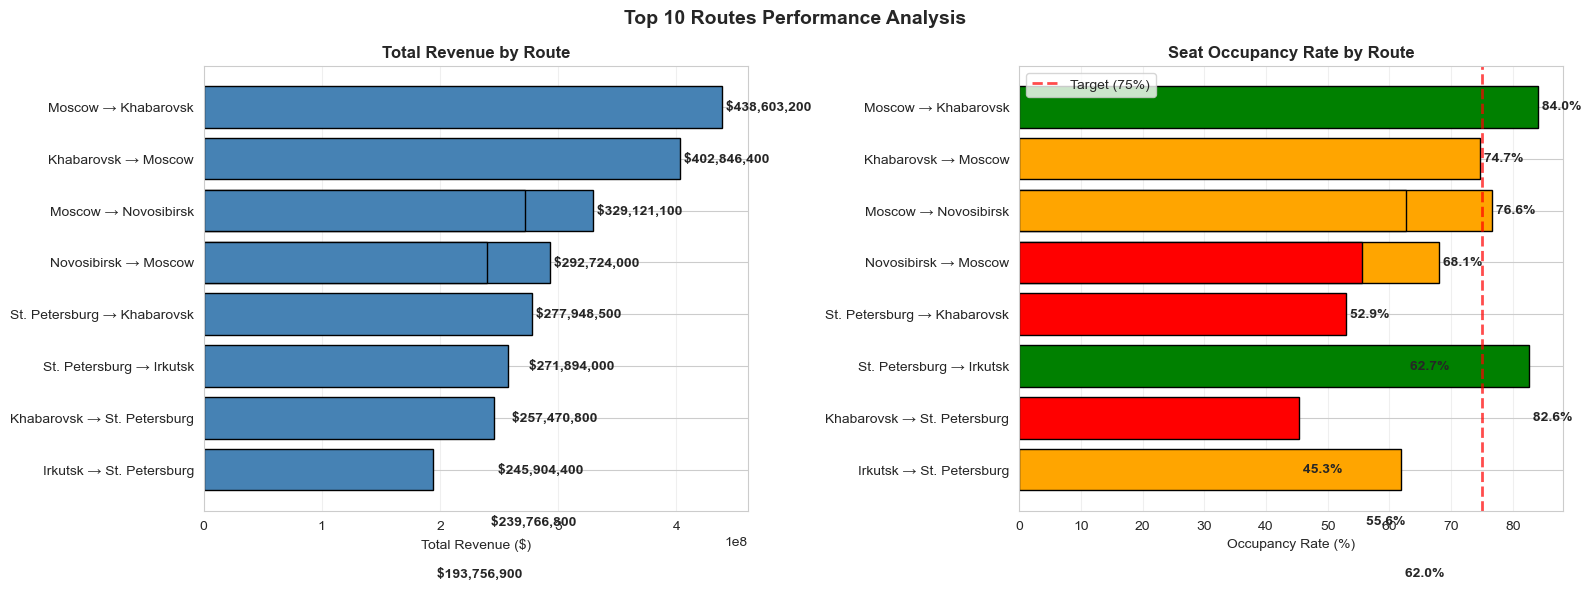

✅ Top routes visualization complete!


In [63]:
# ============================================================================
# VIZ 3: TOP ROUTES ANALYSIS
# Show most profitable and busiest routes
# ============================================================================

print("\nGenerating Top Routes Visualizations...")

# Get top 10 routes for visualization
top_routes = route_revenue.head(10).copy()
top_routes['route'] = top_routes['departure_city'] + ' → ' + top_routes['arrival_city']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Routes Performance Analysis', fontsize=14, fontweight='bold')

# Plot 1: Revenue by route
axes[0].barh(top_routes['route'], top_routes['total_revenue'], color='steelblue', edgecolor='black')
axes[0].set_title('Total Revenue by Route', fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].invert_yaxis()  # Highest on top
# Add value labels
for i, v in enumerate(top_routes['total_revenue']):
    axes[0].text(v, i, f' ${v:,.0f}', va='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Seat occupancy by route
colors_occupancy = ['green' if x > 80 else 'orange' if x > 60 else 'red' for x in top_routes['seat_occupancy_percent']]
axes[1].barh(top_routes['route'], top_routes['seat_occupancy_percent'], color=colors_occupancy, edgecolor='black')
axes[1].set_title('Seat Occupancy Rate by Route', fontweight='bold')
axes[1].set_xlabel('Occupancy Rate (%)')
axes[1].invert_yaxis()
axes[1].axvline(x=75, color='red', linestyle='--', linewidth=2, label='Target (75%)', alpha=0.7)
# Add value labels
for i, v in enumerate(top_routes['seat_occupancy_percent']):
    axes[1].text(v, i, f' {v:.1f}%', va='center', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✅ Top routes visualization complete!")

In [64]:
# ============================================================================
# VIZ 4: TEMPORAL TRENDS
# Show booking and revenue patterns over time
# ============================================================================

print("\nGenerating Temporal Trends Visualizations...")

# Prepare temporal data for plotting
temporal_data_plot = temporal_data.copy()
temporal_data_plot['date'] = pd.to_datetime(temporal_data_plot['booking_month'])
temporal_data_plot


Generating Temporal Trends Visualizations...


,booking_month,month_number,total_bookings,total_tickets,total_revenue,avg_ticket_price,unique_customers,date
0,2017-06,6,7303,10160,557361000,19338.04,10160,2017-06-01
1,2017-07,7,167062,232755,13234251800,19979.03,232755,2017-07-01
2,2017-08,8,88423,123818,6975368100,19676.80,123818,2017-08-01


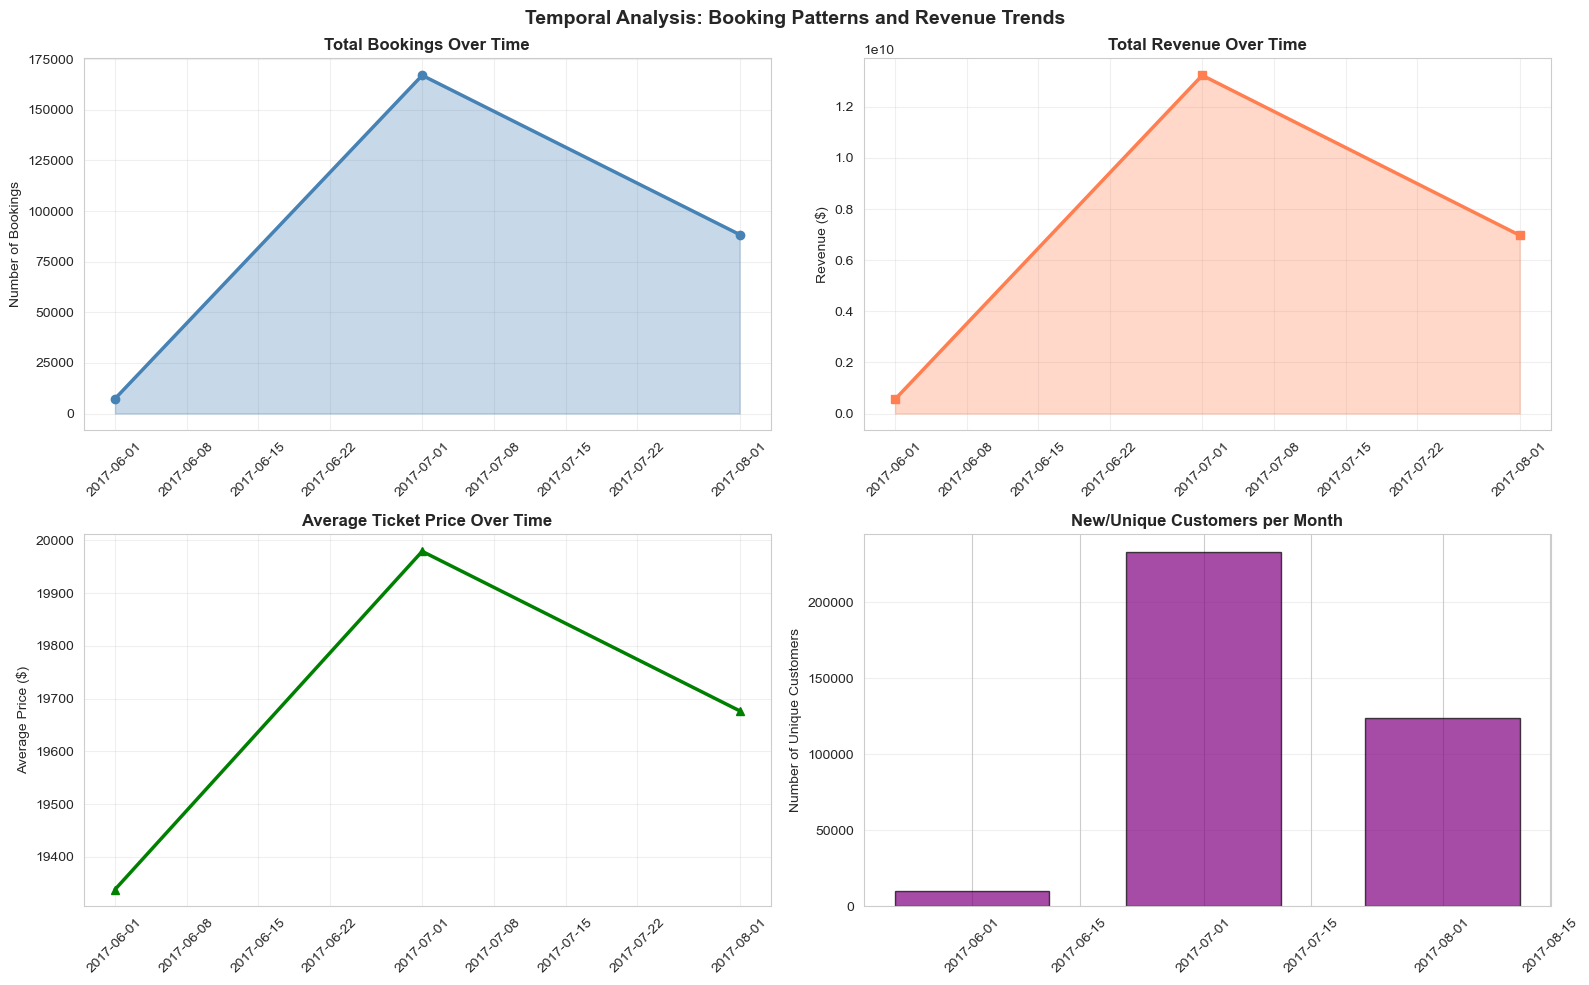

✅ Temporal trends visualization complete!


In [65]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Temporal Analysis: Booking Patterns and Revenue Trends', fontsize=14, fontweight='bold')

# Plot 1: Total bookings over time
axes[0, 0].plot(temporal_data_plot['date'], temporal_data_plot['total_bookings'], 
                marker='o', linewidth=2.5, markersize=6, color='steelblue')
axes[0, 0].fill_between(temporal_data_plot['date'], temporal_data_plot['total_bookings'], alpha=0.3, color='steelblue')
axes[0, 0].set_title('Total Bookings Over Time', fontweight='bold')
axes[0, 0].set_ylabel('Number of Bookings')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Total revenue over time
axes[0, 1].plot(temporal_data_plot['date'], temporal_data_plot['total_revenue'], 
                marker='s', linewidth=2.5, markersize=6, color='coral')
axes[0, 1].fill_between(temporal_data_plot['date'], temporal_data_plot['total_revenue'], alpha=0.3, color='coral')
axes[0, 1].set_title('Total Revenue Over Time', fontweight='bold')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Average ticket price over time
axes[1, 0].plot(temporal_data_plot['date'], temporal_data_plot['avg_ticket_price'], 
                marker='^', linewidth=2.5, markersize=6, color='green')
axes[1, 0].set_title('Average Ticket Price Over Time', fontweight='bold')
axes[1, 0].set_ylabel('Average Price ($)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Unique customers over time
axes[1, 1].bar(temporal_data_plot['date'], temporal_data_plot['unique_customers'], 
               color='purple', alpha=0.7, edgecolor='black', width=20)
axes[1, 1].set_title('New/Unique Customers per Month', fontweight='bold')
axes[1, 1].set_ylabel('Number of Unique Customers')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Temporal trends visualization complete!")


Generating Aircraft Performance Visualizations...


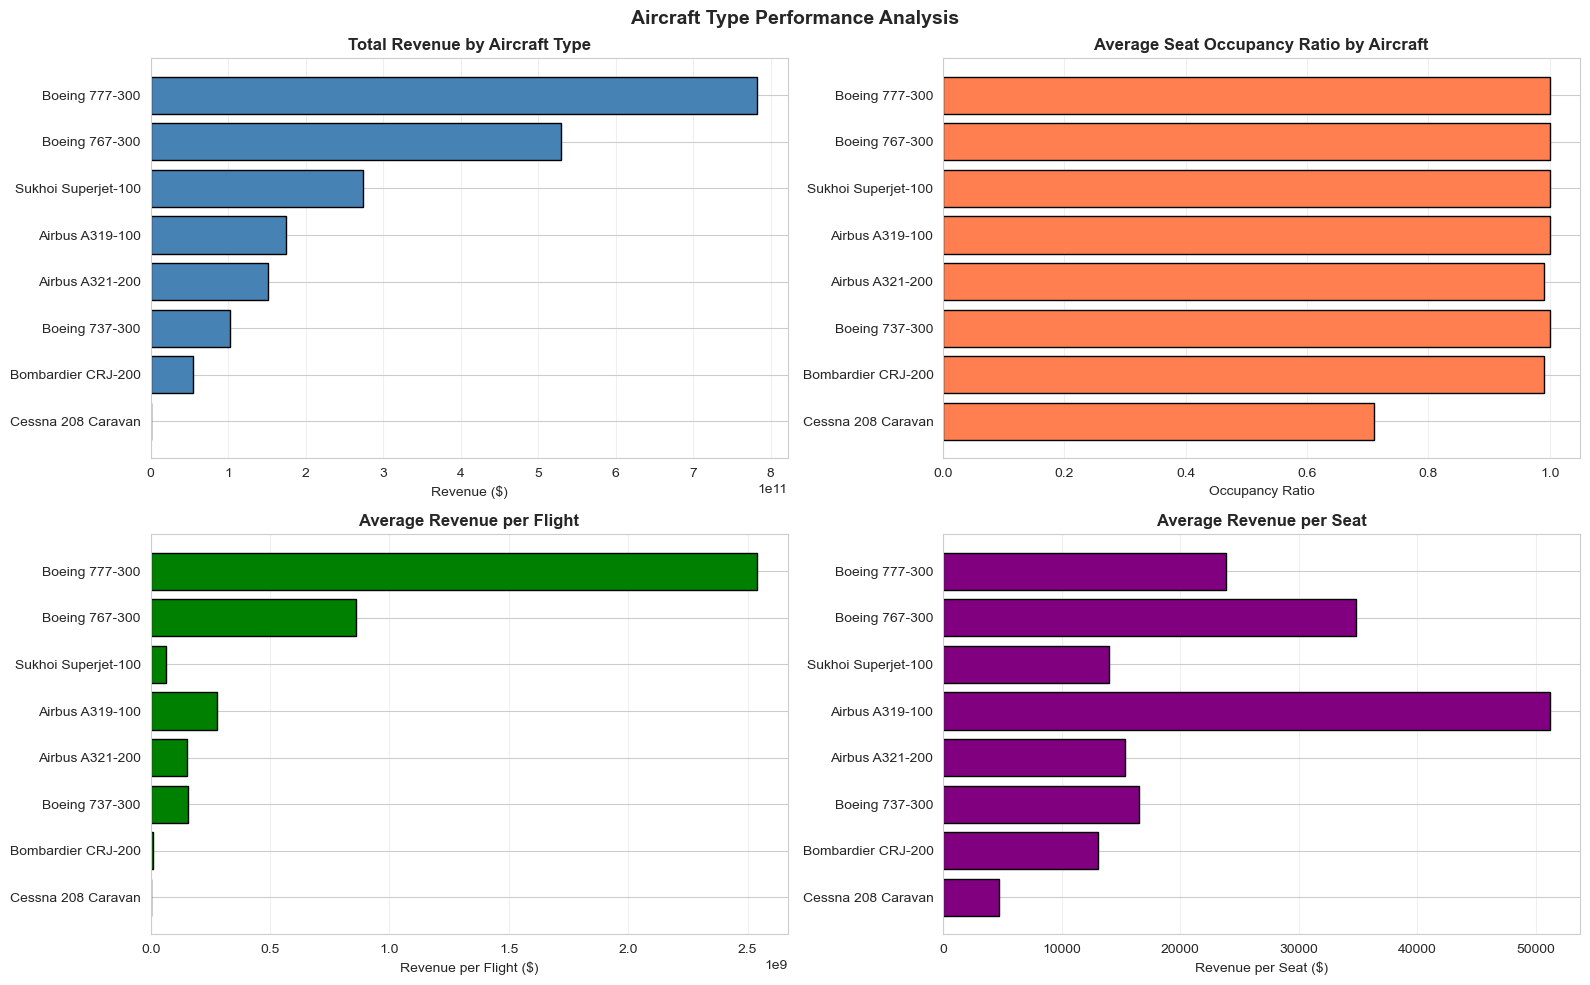

 Aircraft performance visualization complete!


In [66]:
# ============================================================================
# VIZ 5: AIRCRAFT PERFORMANCE
# Compare revenue and efficiency across aircraft types
# ============================================================================

print("\nGenerating Aircraft Performance Visualizations...")

# Get top aircraft by revenue
top_aircraft = aircraft_perf[aircraft_perf['total_revenue'] > 0].head(10).copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Aircraft Type Performance Analysis', fontsize=14, fontweight='bold')

# Plot 1: Revenue by aircraft
axes[0, 0].barh(top_aircraft['aircraft_model'], top_aircraft['total_revenue'], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Total Revenue by Aircraft Type', fontweight='bold')
axes[0, 0].set_xlabel('Revenue ($)')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Plot 2: Occupancy ratio by aircraft
axes[0, 1].barh(top_aircraft['aircraft_model'], top_aircraft['avg_occupancy_ratio'], color='coral', edgecolor='black')
axes[0, 1].set_title('Average Seat Occupancy Ratio by Aircraft', fontweight='bold')
axes[0, 1].set_xlabel('Occupancy Ratio')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Revenue per flight
axes[1, 0].barh(top_aircraft['aircraft_model'], top_aircraft['revenue_per_flight'], color='green', edgecolor='black')
axes[1, 0].set_title('Average Revenue per Flight', fontweight='bold')
axes[1, 0].set_xlabel('Revenue per Flight ($)')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Revenue per seat
axes[1, 1].barh(top_aircraft['aircraft_model'], top_aircraft['revenue_per_seat'], color='purple', edgecolor='black')
axes[1, 1].set_title('Average Revenue per Seat', fontweight='bold')
axes[1, 1].set_xlabel('Revenue per Seat ($)')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(" Aircraft performance visualization complete!")

### 8. CUSTOMER SEGMENTATION

Use machine learning to identify customer segments

In [ ]:
customer_segment_data.head()

In [68]:
# ============================================================================
# CUSTOMER SEGMENTATION: K-MEANS CLUSTERING
# Identify natural customer groups based on behavior
# ============================================================================

print("\n" + "="*70)
print("CUSTOMER SEGMENTATION ANALYSIS")
print("="*70)

# Prepare data for clustering
# Select features for segmentation
features_for_clustering = customer_segment_data[[
    'lifetime_value', 
    'booking_frequency', 
    'avg_transaction_value',
    'days_since_last_booking'
]].copy()

# Handle missing/infinite values
features_for_clustering = features_for_clustering.fillna(0)
features_for_clustering = features_for_clustering.replace([np.inf, -np.inf], 0)

# Standardize the features (important for K-means)
# Standardization means: (value - mean) / standard deviation
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_clustering)

print("\n✓ Data prepared and standardized for clustering")
print(f"  Number of customers: {len(features_scaled)}")
print(f"  Number of features: {features_scaled.shape[1]}")


CUSTOMER SEGMENTATION ANALYSIS

✓ Data prepared and standardized for clustering
  Number of customers: 366733
  Number of features: 4



Finding optimal number of customer segments...



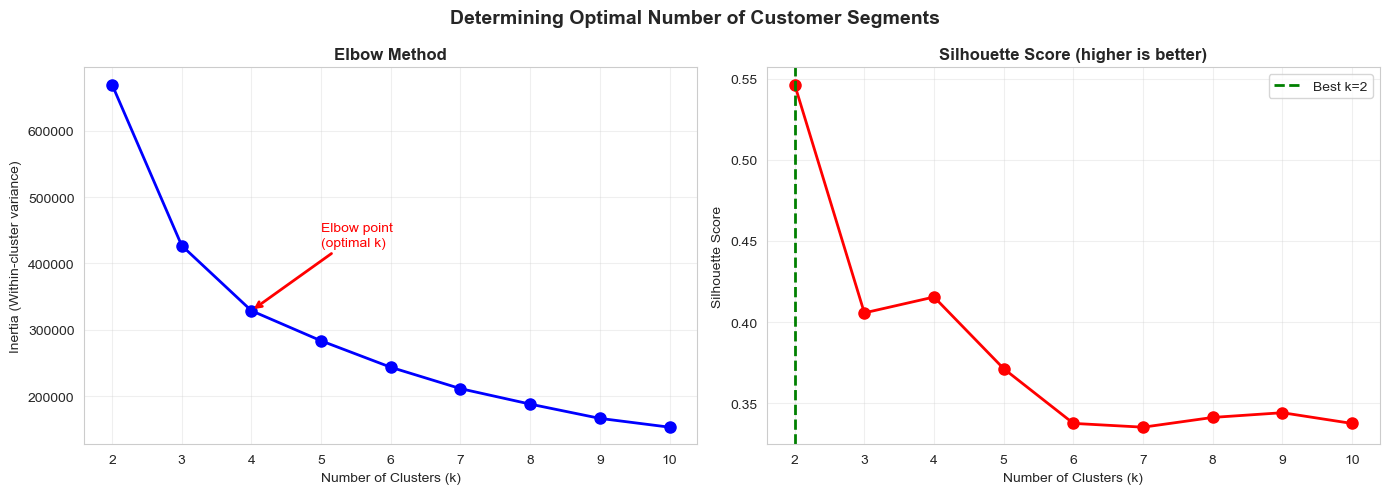


✅ Recommended number of segments: 2
   (Based on silhouette score analysis)


In [69]:
# ============================================================================
# FIND OPTIMAL NUMBER OF CLUSTERS (Elbow Method)
# Determine best number of customer segments
# ============================================================================

print("\nFinding optimal number of customer segments...\n")

# Try different numbers of clusters and calculate inertia (within-cluster variance)
inertias = []  # Sum of distances from each point to its cluster center
silhouette_scores = []  # Measure of how similar points are within their cluster
K_range = range(2, 11)  # Try 2 to 10 clusters

from sklearn.metrics import silhouette_score

for k in K_range:
    # Fit K-means with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)  # Record the inertia
    # Silhouette score ranges from -1 to 1 (higher is better)
    score = silhouette_score(features_scaled, kmeans.labels_,  sample_size=5000,random_state=42)
    silhouette_scores.append(score)



# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Determining Optimal Number of Customer Segments', fontsize=14, fontweight='bold')

# Plot 1: Elbow method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster variance)')
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Elbow point\n(optimal k)', xy=(4, inertias[2]), xytext=(5, inertias[1]),
                arrowprops=dict(arrowstyle='->', color='red', lw=2), fontsize=10, color='red')

# Plot 2: Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score (higher is better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k, color='green', linestyle='--', linewidth=2, label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Recommend optimal k
optimal_k = best_k
print(f"\n✅ Recommended number of segments: {optimal_k}")
print(f"   (Based on silhouette score analysis)")



In [70]:
# ============================================================================
# PERFORM FINAL CLUSTERING WITH OPTIMAL K
# Create customer segments
# ============================================================================

# Perform K-means clustering with optimal k
optimal_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = optimal_kmeans.fit_predict(features_scaled)

# Add cluster assignments to customer data
customer_segment_data['segment'] = cluster_labels

print(f"\n Clustering complete with {optimal_k} segments\n")


 Clustering complete with 2 segments



In [71]:
customer_segment_data.segment.value_counts().sort_index()

segment
0     45312
1    321421
Name: count, dtype: int64

In [72]:
# Analyze each segment
print("CUSTOMER SEGMENT PROFILES:")
print("="*70)

segment_profiles = customer_segment_data.groupby('segment').agg({
    'passenger_id': 'count',  # Number of customers in segment
    'lifetime_value': ['mean', 'median', 'min', 'max'],  # Value metrics
    'avg_transaction_value': 'mean',  # Transaction size
    'days_since_last_booking': 'mean',  # Recency
    'business_class_flights': 'mean',  # Premium preference
}).round(2)
segment_profiles

CUSTOMER SEGMENT PROFILES:


passenger_id lifetime_value                           \
               count           mean    median    min     max   
segment                                                        
0              45312      155736.76 135600.00  61500  529500   
1             321421       42655.07  38400.00   3400  127000   

        avg_transaction_value days_since_last_booking business_class_flights  
                         mean                    mean                   mean  
segment                                                                       
0                    59223.75                   22.22                   0.59  
1                    15505.98                   22.15                   0.21

In [73]:
# Rename columns for clarity
segment_profiles.columns = ['_'.join(col).strip() for col in segment_profiles.columns.values]
segment_profiles

,passenger_id_count,lifetime_value_mean,lifetime_value_median,lifetime_value_min,lifetime_value_max,avg_transaction_value_mean,days_since_last_booking_mean,business_class_flights_mean
segment,,,,,,,,
0,45312,155736.76,135600.00,61500,529500,59223.75,22.22,0.59
1,321421,42655.07,38400.00,3400,127000,15505.98,22.15,0.21


In [74]:
# Create descriptive names for segments based on characteristics
segment_names = {}
for seg in range(optimal_k):
    seg_data = customer_segment_data[customer_segment_data['segment'] == seg]
    avg_value = seg_data['lifetime_value'].mean()
    avg_freq = seg_data['booking_frequency'].mean()
    
    if avg_value > customer_segment_data['lifetime_value'].quantile(0.75) and avg_freq > customer_segment_data['booking_frequency'].median():
        segment_names[seg] = 'VIP (High Value, Frequent)'
    elif avg_value > customer_segment_data['lifetime_value'].quantile(0.75):
        segment_names[seg] = 'High Value (occasional)'
    elif avg_freq > customer_segment_data['booking_frequency'].median():
        segment_names[seg] = 'Loyal (Frequent, Lower spend)'
    else:
        segment_names[seg] = 'At-Risk (Low value/frequency)'

print("\n" + "="*70)
print("SEGMENT NAMES & INTERPRETATIONS:")
print("="*70)
for seg, name in segment_names.items():
    count = len(customer_segment_data[customer_segment_data['segment'] == seg])
    pct = count / len(customer_segment_data) * 100
    revenue = customer_segment_data[customer_segment_data['segment'] == seg]['lifetime_value'].sum()
    print(f"\nSegment {seg}: {name}")
    print(f"  Customers: {count} ({pct:.1f}%)")
    print(f"  Total Revenue: ${revenue:,.0f}")
    print(f"  Avg Customer Value: ${revenue/count:,.0f}")


SEGMENT NAMES & INTERPRETATIONS:

Segment 0: High Value (occasional)
  Customers: 45312 (12.4%)
  Total Revenue: $7,056,744,200
  Avg Customer Value: $155,737

Segment 1: At-Risk (Low value/frequency)
  Customers: 321421 (87.6%)
  Total Revenue: $13,710,236,700
  Avg Customer Value: $42,655



Generating segment visualizations...



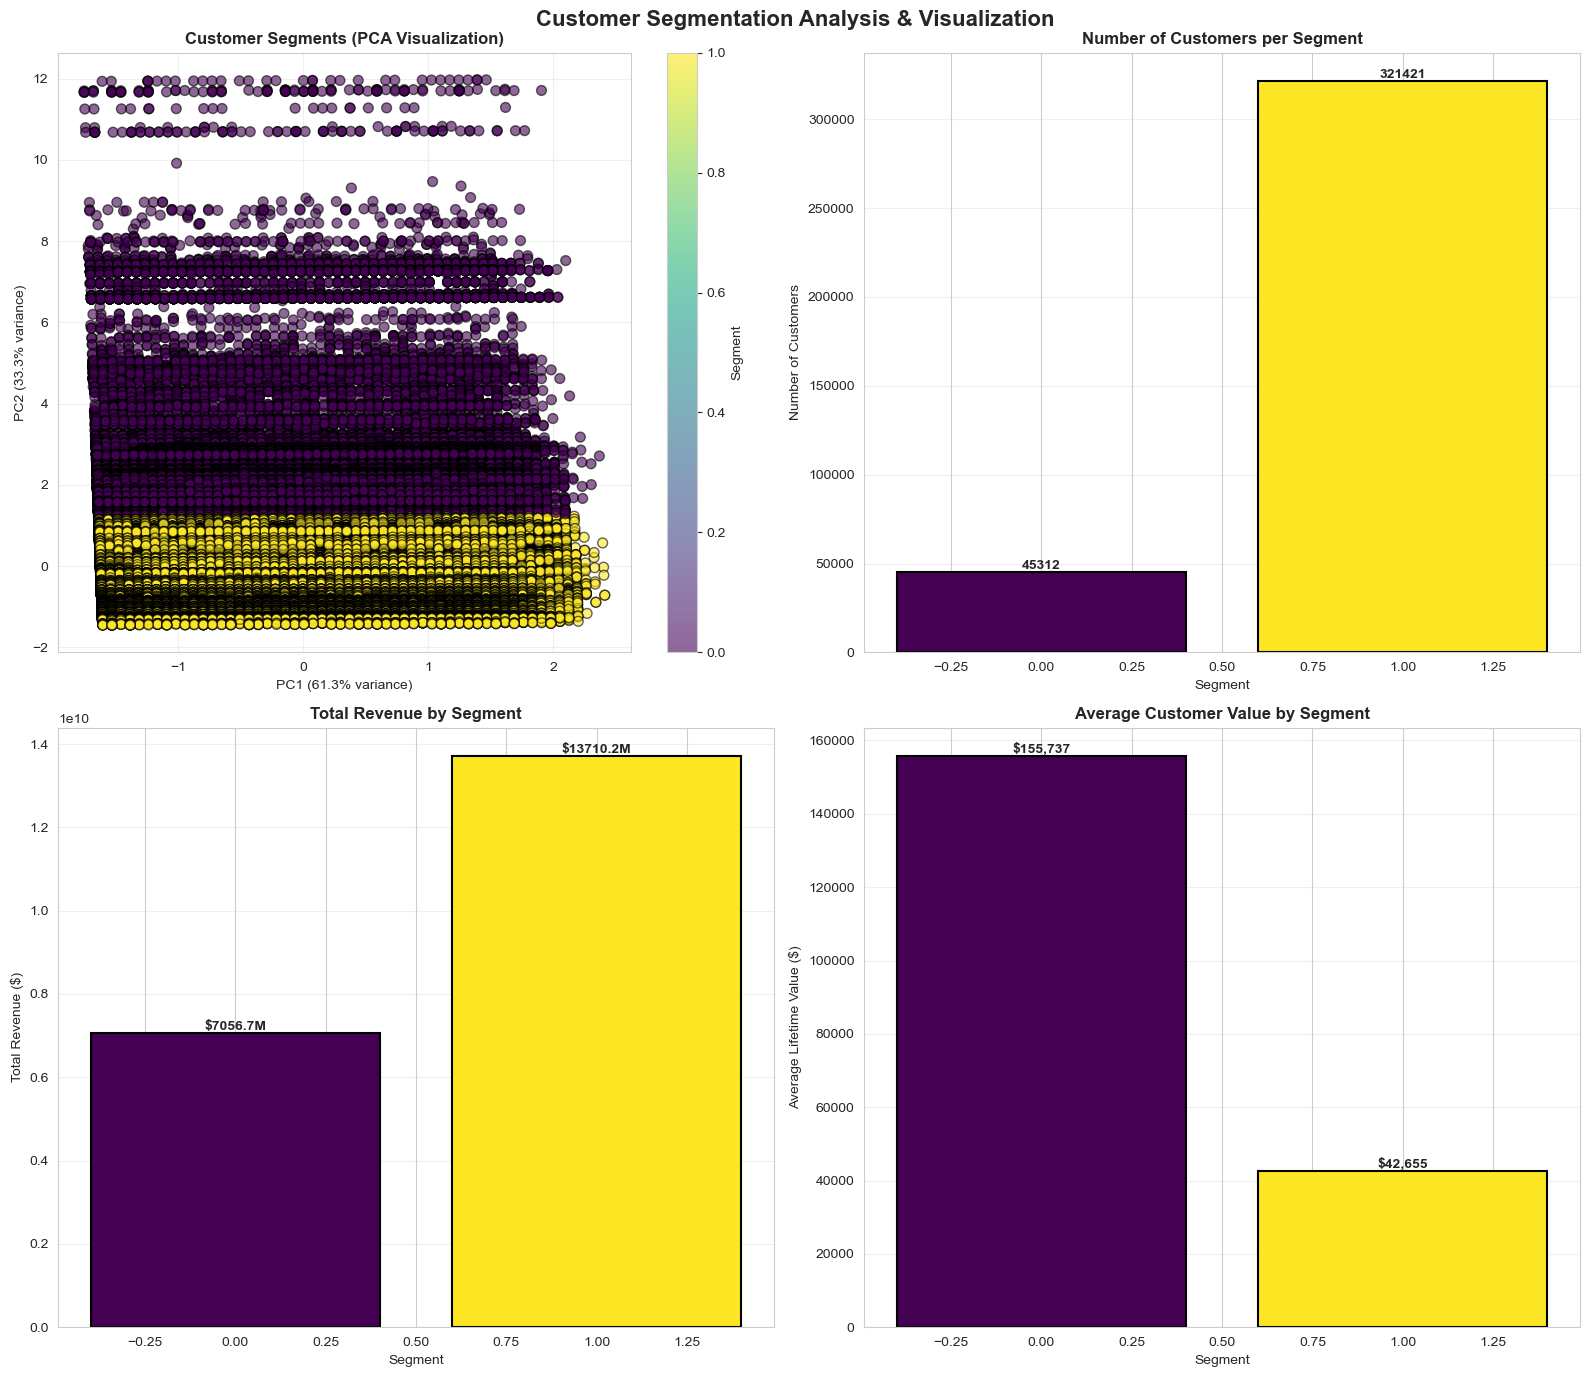

 Segmentation visualization complete!


In [77]:
# ============================================================================
# VISUALIZE CUSTOMER SEGMENTS
# Create visual representation of segments
# ============================================================================

print("\nGenerating segment visualizations...\n")

# Use PCA to reduce dimensions for visualization
# PCA finds new axes that capture most variance in data
pca = PCA(n_components=2)  # Reduce to 2D for plotting
features_2d = pca.fit_transform(features_scaled)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Customer Segmentation Analysis & Visualization', fontsize=16, fontweight='bold')

# Plot 1: Clusters in 2D PCA space
scatter = axes[0, 0].scatter(features_2d[:, 1], features_2d[:, 0], 
                             c=cluster_labels, cmap='viridis', s=50, alpha=0.6, edgecolors='black')
axes[0, 0].set_title('Customer Segments (PCA Visualization)', fontweight='bold')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
cbar = plt.colorbar(scatter, ax=axes[0, 0])
cbar.set_label('Segment')
axes[0, 0].grid(True, alpha=0.3)


# Plot 2: Segment size
segment_counts = customer_segment_data['segment'].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))
bars = axes[0, 1].bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('Number of Customers per Segment', fontweight='bold')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Revenue by segment
segment_revenue = customer_segment_data.groupby('segment')['lifetime_value'].sum().sort_index()
bars = axes[1, 0].bar(segment_revenue.index, segment_revenue.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Total Revenue by Segment', fontweight='bold')
axes[1, 0].set_xlabel('Segment')
axes[1, 0].set_ylabel('Total Revenue ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')
# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'${height/1e6:.1f}M', ha='center', va='bottom', fontweight='bold')

# Plot 4: Average customer value by segment
segment_avg_value = customer_segment_data.groupby('segment')['lifetime_value'].mean().sort_index()
bars = axes[1, 1].bar(segment_avg_value.index, segment_avg_value.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1, 1].set_title('Average Customer Value by Segment', fontweight='bold')
axes[1, 1].set_xlabel('Segment')
axes[1, 1].set_ylabel('Average Lifetime Value ($)')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'${height:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(" Segmentation visualization complete!")


In [78]:
pca.explained_variance_ratio_[1] + pca.explained_variance_ratio_[0]

0.946445985211373